# Regression Trees

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

In [2]:
dataset = pd.read_csv('/content/50_Startups.csv')
dataset.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


### TODO 1

Remova as colunas Administration e State do dataset

In [3]:
#resposta
dataset.drop(['Administration', 'State'], axis=1, inplace=True)
dataset.head()

,R&D Spend,Marketing Spend,Profit
0,165349.20,471784.10,192261.83
1,162597.70,443898.53,191792.06
2,153441.51,407934.54,191050.39
3,144372.41,383199.62,182901.99
4,142107.34,366168.42,166187.94


### TODO 2
Separe o dataset em vetor de características e variável meta

In [5]:
#resposta
X = dataset.drop(columns=['Profit'])
y = dataset['Profit']

### TODO 3
Treine um modelo de regressão usando Regression Tree

In [8]:
from sklearn.model_selection import train_test_split

# X representa as variáveis independentes (características)
# y representa a variável dependente (alvo/target)

# Dividindo os dados: 70% para treino e 30% para teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 1. Instanciar o modelo
modelo = DecisionTreeRegressor(random_state=42)

# 2. Treinar o modelo com os dados de entrada (X) e o alvo (y)
modelo.fit(X_train, y_train)

# 3. Fazer previsões
previsoes = modelo.predict(X_test)

print(previsoes)


[144259.4   96479.51  97483.56  49490.75 124266.9   42559.73 108552.04
 103282.38 101004.64 146121.95 144259.4  156991.12  96479.51 124266.9
 191050.39]


### TODO 4
Suponha que a empresa tenha um orçamento de R$ 500.000,00.

Eles estão considerando três opções:

> R&D: 300.000,00 ; Marketing: 200.000,00

> R&D: 200.000,00 ; Marketing: 300.000,00

> R&D: 100.000,00 ; Marketing: 400.000,00

Qual opção irá, a partir do modelo treinado, retornar o maior lucro?

In [9]:
cenarios = pd.DataFrame({
    'R&D Spend': [300000.00, 200000.00, 100000.00],
    'Marketing Spend': [200000.00, 300000.00, 400000.00]
})

# 2. Use o seu modelo treinado (supondo que o nome da variável seja 'modelo') para prever o lucro
# Subtitua 'modelo' pelo nome da variável do seu DecisionTreeRegressor
cenarios['Lucro_Previsto'] = modelo.predict(cenarios)

# 3. Identifica a opção com o maior lucro
melhor_opcao = cenarios.loc[cenarios['Lucro_Previsto'].idxmax()]

print("Previsões para cada cenário:")
print(cenarios)
print("\nA melhor opção com base no modelo é:")
print(melhor_opcao)

Previsões para cada cenário:
   R&D Spend  Marketing Spend  Lucro_Previsto
0   300000.0         200000.0       191050.39
1   200000.0         300000.0       191050.39
2   100000.0         400000.0       124266.90

A melhor opção com base no modelo é:
R&D Spend          300000.00
Marketing Spend    200000.00
Lucro_Previsto     191050.39
Name: 0, dtype: float64


# Decision Trees

In [10]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn import metrics

In [15]:
#fazendo o download dos dados direto dos datasets presente na scikit-learn
data = datasets.load_breast_cancer()
data.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [12]:
#variável meta (target) -> aquilos que estamos tentando prever
#no caso: cancer benigno ou maligno
data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [13]:
#linhas x colunas
data.data.shape

(569, 30)

In [14]:
#visualizando as 5 primeiras amostras
data.data[0:5]

array([[1.799e+01, 1.038e+01, 1.228e+02, 1.001e+03, 1.184e-01, 2.776e-01,
        3.001e-01, 1.471e-01, 2.419e-01, 7.871e-02, 1.095e+00, 9.053e-01,
        8.589e+00, 1.534e+02, 6.399e-03, 4.904e-02, 5.373e-02, 1.587e-02,
        3.003e-02, 6.193e-03, 2.538e+01, 1.733e+01, 1.846e+02, 2.019e+03,
        1.622e-01, 6.656e-01, 7.119e-01, 2.654e-01, 4.601e-01, 1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, 1.326e+03, 8.474e-02, 7.864e-02,
        8.690e-02, 7.017e-02, 1.812e-01, 5.667e-02, 5.435e-01, 7.339e-01,
        3.398e+00, 7.408e+01, 5.225e-03, 1.308e-02, 1.860e-02, 1.340e-02,
        1.389e-02, 3.532e-03, 2.499e+01, 2.341e+01, 1.588e+02, 1.956e+03,
        1.238e-01, 1.866e-01, 2.416e-01, 1.860e-01, 2.750e-01, 8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, 1.203e+03, 1.096e-01, 1.599e-01,
        1.974e-01, 1.279e-01, 2.069e-01, 5.999e-02, 7.456e-01, 7.869e-01,
        4.585e+00, 9.403e+01, 6.150e-03, 4.006e-02, 3.832e-02, 2.058e-02,
        2.250e-02, 4.571e-03, 2.357e

## TODO 1
> Separe o dataset em conjunto de treino e teste, sendo 70% para treino e 30% para teste

In [17]:
X = data.data
y = data.target

# Dividindo os dados: 70% para treino e 30% para teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


## TODO 2
> Treine uma Árvore de Decisão. Teste com diferentes valores de max_depth e compare os resultados

max_depth    | Acurácia Treino  | Acurácia Teste 
--------------------------------------------------


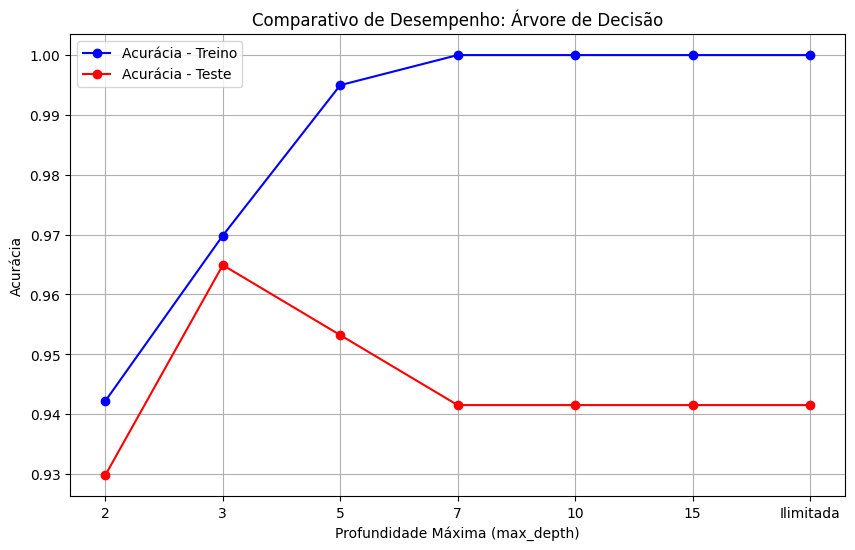

In [19]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Definir os valores de max_depth que deseja testar
profundidades = [2, 3, 5, 7, 10, 15, None]

# Listas para armazenar os resultados de desempenho
treino_acc = []
teste_acc = []

print(f"{'max_depth':<12} | {'Acurácia Treino':<16} | {'Acurácia Teste':<15}")
print("-" * 50)

# 2. Treinar e avaliar o modelo para cada profundidade
for depth in profundidades:
    # Inicializa o modelo (ajuste o random_state para garantir reprodutibilidade)
    dt_model = DecisionTreeClassifier(max_depth=depth, random_state=42)

    # Treina o modelo com os dados de treino (substitua por X_train e y_train)
    dt_model.fit(X_train, y_train)

    # Predições
    y_pred_train = dt_model.predict(X_train)
    y_pred_test = dt_model.predict(X_test)

    # Calcula as acurácias
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    # Armazena os resultados para o gráfico
    treino_acc.append(acc_train)
    teste_acc.append(acc_test)

    # Exibe os resultados em formato de tabela
    depth_str = str(depth) if depth is not None else "Ilimitada"
    # print(f"{depth_str:<12} | {acc_train:.4f}:<16} | {acc_test:.4f}")

# 3. Plottar o gráfico de comparação para análise visual
plt.figure(figsize=(10, 6))
# Substitui 'None' por uma string ou número alto para o eixo X do gráfico
x_axis = [str(d) if d is not None else "Ilimitada" for d in profundidades]

plt.plot(x_axis, treino_acc, label='Acurácia - Treino', marker='o', color='blue')
plt.plot(x_axis, teste_acc, label='Acurácia - Teste', marker='o', color='red')

plt.xlabel('Profundidade Máxima (max_depth)')
plt.ylabel('Acurácia')
plt.title('Comparativo de Desempenho: Árvore de Decisão')
plt.legend()
plt.grid(True)
plt.show()


## TODO 3
> Faça a predição para o conjunto de teste

In [20]:
y_pred = dt_model.predict(X_test)


print(y_pred[:10])

[1 0 0 1 1 0 0 0 1 1]


## TODO 4

> Imprima a matriz de confusão (usando a Scikit-Learn)

> Obtenha a Acurácia, Precision, Recall e F1-Score

In [21]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# IMPORTANTE: Substitua 'y_test' e 'y_pred' pelas suas variáveis reais
# y_test: seus dados reais de teste
# y_pred: as previsões geradas pelo seu modelo (ex: modelo.predict(X_test))

# 1. Imprime a Matriz de Confusão
print("--- MATRIZ DE CONFUSÃO ---")
matriz = confusion_matrix(y_test, y_pred)
print(matriz)
print("\n" + "="*50 + "\n")

# 2. Obtém e imprime a Acurácia de forma isolada
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia Global do Modelo: {acuracia:.4f}\n")

# 3. Obtém Precision, Recall e F1-Score detalhados por classe
print("--- RELATÓRIO DE CLASSIFICAÇÃO (Precision, Recall, F1-Score) ---")
relatorio = classification_report(y_test, y_pred)
print(relatorio)



--- MATRIZ DE CONFUSÃO ---
[[ 60   3]
 [  7 101]]


Acurácia Global do Modelo: 0.9415

--- RELATÓRIO DE CLASSIFICAÇÃO (Precision, Recall, F1-Score) ---
              precision    recall  f1-score   support

           0       0.90      0.95      0.92        63
           1       0.97      0.94      0.95       108

    accuracy                           0.94       171
   macro avg       0.93      0.94      0.94       171
weighted avg       0.94      0.94      0.94       171



In [ ]:
#resposta